# DBGSOM vs. sklearn Clustering — Comparison

This notebook benchmarks DBGSOM (`SomVQ`) against the most comparable sklearn clustering algorithms
on two datasets: **Iris** (small, low-dimensional) and **Digits** (larger, high-dimensional).

## Algorithm Overview

| Property | DBGSOM | KMeans | MiniBatchKMeans | AgglomerativeClustering |
| --- | --- | --- | --- | --- |
| Learning rule | Batch SOM | Lloyd's algorithm | Mini-batch Lloyd | Ward / linkage |
| Prototype count | **Adaptive** (grows from 4) | Fixed (`n_clusters`) | Fixed (`n_clusters`) | Fixed (`n_clusters`) |
| Topology preserved | **Yes** (grid graph) | No | No | No |
| Predict on new data | Yes | Yes | Yes | No |
| sklearn-compatible | **Yes** | Yes | Yes | Yes |
| Complexity (fit) | O(e·(n·m·d + m²·d) + m⁴) | O(n·k·d·e) | O(n·k·d·b) | O(n²·d) |

> **Fair comparison:** DBGSOM is trained first to determine its final neuron count `m`.
> All other algorithms are then configured with `n_clusters = m` so every model uses the same prototype budget.

## Imports

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans, MiniBatchKMeans
from sklearn.datasets import load_digits, load_iris
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

from dbgsom.SomVQ import SomVQ

## Datasets

In [2]:
iris = load_iris()
X_iris = StandardScaler().fit_transform(iris.data)
y_iris = iris.target

digits = load_digits()
X_digits = StandardScaler().fit_transform(digits.data)
y_digits = digits.target

print(
    f"Iris:   {X_iris.shape[0]} samples × {X_iris.shape[1]} features, {len(np.unique(y_iris))} classes"
)
print(
    f"Digits: {X_digits.shape[0]} samples × {X_digits.shape[1]} features, {len(np.unique(y_digits))} classes"
)

Iris:   150 samples × 4 features, 3 classes
Digits: 1797 samples × 64 features, 10 classes


## Helper Functions

In [3]:
def compute_qe(X, labels):
    """Mean Euclidean distance from each sample to its cluster centroid."""
    unique_labels = np.unique(labels)
    centroids = np.array([X[labels == k].mean(axis=0) for k in unique_labels])
    label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
    centroid_idx = np.array([label_to_idx[lbl] for lbl in labels])
    return float(np.mean(np.linalg.norm(X - centroids[centroid_idx], axis=1)))


def build_row(X, y_true, labels, name, t, qe=None, te=None):
    return {
        "Algorithm": name,
        "Time (s)": round(t, 3),
        "Clusters": int(len(np.unique(labels))),
        "ARI": round(adjusted_rand_score(y_true, labels), 3),
        "Silhouette": round(silhouette_score(X, labels), 3),
        "Davies-Bouldin": round(davies_bouldin_score(X, labels), 3),
        "Calinski-Harabasz": round(calinski_harabasz_score(X, labels), 1),
        "QE": round(qe if qe is not None else compute_qe(X, labels), 4),
        "Topographic Error": round(te, 4) if te is not None else "—",
    }


def plot_metrics(rows, dataset_name):
    df = pd.DataFrame(rows).set_index("Algorithm")
    metric_specs = [
        ("ARI", "ARI (↑ better)"),
        ("Silhouette", "Silhouette (↑ better)"),
        ("Davies-Bouldin", "Davies-Bouldin (↓ better)"),
        ("Time (s)", "Training time / s (↓ better)"),
    ]
    colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f"Metric comparison — {dataset_name}", fontsize=13)
    for ax, (col, label) in zip(axes, metric_specs):
        vals = df[col].astype(float)
        bars = ax.bar(vals.index, vals.values, color=colors[: len(vals)])
        ax.set_title(label, fontsize=10)
        ax.tick_params(axis="x", rotation=25, labelsize=9)
        for bar, val in zip(bars, vals.values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{val:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
            )
    plt.tight_layout()
    plt.show()


def plot_pca_clusters(X, labels_dict, dataset_name):
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X)
    n_algs = len(labels_dict)
    fig, axes = plt.subplots(1, n_algs, figsize=(5 * n_algs, 4))
    fig.suptitle(f"Cluster assignments in PCA space — {dataset_name}", fontsize=13)
    for ax, (name, labels) in zip(axes, labels_dict.items()):
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap="tab20", s=10, alpha=0.7)
        n = len(np.unique(labels))
        ax.set_title(f"{name}\n({n} clusters)", fontsize=10)
        ax.set_xlabel("PC 1")
        ax.set_ylabel("PC 2")
        ax.tick_params(labelsize=8)
    plt.tight_layout()
    plt.show()

---
## Dataset 1: Iris

150 samples, 4 features, 3 ground-truth classes.
A small, well-separated dataset — good for a sanity check.

In [14]:
# --- DBGSOM (determines n_clusters for all other algorithms) ---
t0 = time.perf_counter()
som_iris = SomVQ(n_iter=200, spreading_factor=0.5, max_neurons=20, random_state=42)
som_iris.fit(X_iris)
t_som = time.perf_counter() - t0
n_clusters_iris = len(som_iris.neurons_)
labels_som = som_iris.predict(X_iris)
print(f"DBGSOM:  {n_clusters_iris} neurons in {t_som:.3f}s")

# --- KMeans ---
t0 = time.perf_counter()
km_iris = KMeans(n_clusters=n_clusters_iris, random_state=42, n_init=10)
km_iris.fit(X_iris)
t_km = time.perf_counter() - t0
labels_km = km_iris.labels_
print(f"KMeans:  {n_clusters_iris} clusters in {t_km:.3f}s")

# --- MiniBatchKMeans ---
t0 = time.perf_counter()
mbkm_iris = MiniBatchKMeans(n_clusters=n_clusters_iris, random_state=42, n_init=10)
mbkm_iris.fit(X_iris)
t_mbkm = time.perf_counter() - t0
labels_mbkm = mbkm_iris.labels_
print(f"MiniBatch: {n_clusters_iris} clusters in {t_mbkm:.3f}s")

# --- AgglomerativeClustering ---
t0 = time.perf_counter()
agg_iris = AgglomerativeClustering(n_clusters=n_clusters_iris)
labels_agg = agg_iris.fit_predict(X_iris)
t_agg = time.perf_counter() - t0
print(f"Agglom.: {n_clusters_iris} clusters in {t_agg:.3f}s")

DBGSOM:  4 neurons in 0.081s
KMeans:  4 clusters in 0.025s
MiniBatch: 4 clusters in 0.075s
Agglom.: 4 clusters in 0.002s


### Metrics — Iris

* **ARI** (Adjusted Rand Index): measures agreement with the ground-truth labels, 1 = perfect.
* **Silhouette**: measures within-cluster cohesion vs. between-cluster separation, 1 = perfect.
* **Davies-Bouldin**: ratio of within- to between-cluster scatter, lower is better.
* **QE** (Quantization Error): mean Euclidean distance from each sample to its assigned centroid.
* **Topographic Error**: fraction of samples whose 1st and 2nd BMU are not adjacent on the grid (DBGSOM only).

In [15]:
rows_iris = [
    build_row(
        X_iris,
        y_iris,
        labels_som,
        "DBGSOM",
        t_som,
        qe=som_iris.quantization_error_,
        te=som_iris.topographic_error_,
    ),
    build_row(X_iris, y_iris, labels_km, "KMeans", t_km),
    build_row(X_iris, y_iris, labels_mbkm, "MiniBatchKMeans", t_mbkm),
    build_row(X_iris, y_iris, labels_agg, "AgglomerativeClustering", t_agg),
]

df_iris = pd.DataFrame(rows_iris).set_index("Algorithm")
df_iris

,Time (s),Clusters,ARI,Silhouette,Davies-Bouldin,Calinski-Harabasz,QE,Topographic Error
Algorithm,,,,,,,,
DBGSOM,0.081,4,0.666,0.283,0.811,141.8,1.0238,0.1667
KMeans,0.025,4,0.473,0.387,0.870,207.3,0.7764,—
MiniBatchKMeans,0.075,4,0.579,0.413,0.922,206.1,0.7755,—
AgglomerativeClustering,0.002,4,0.588,0.401,0.979,201.3,0.7848,—


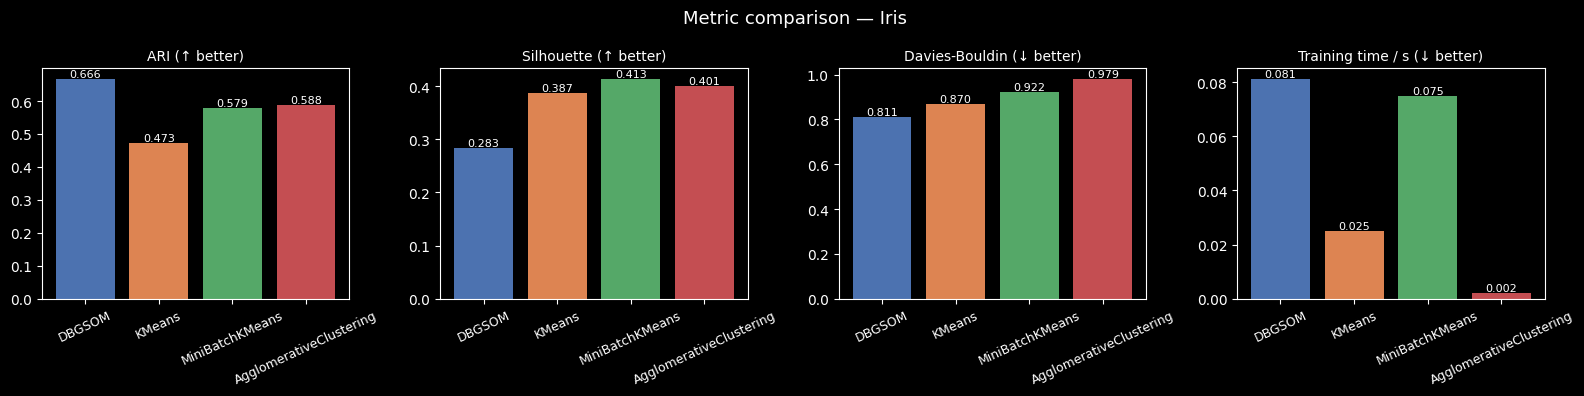

In [16]:
plot_metrics(rows_iris, "Iris")

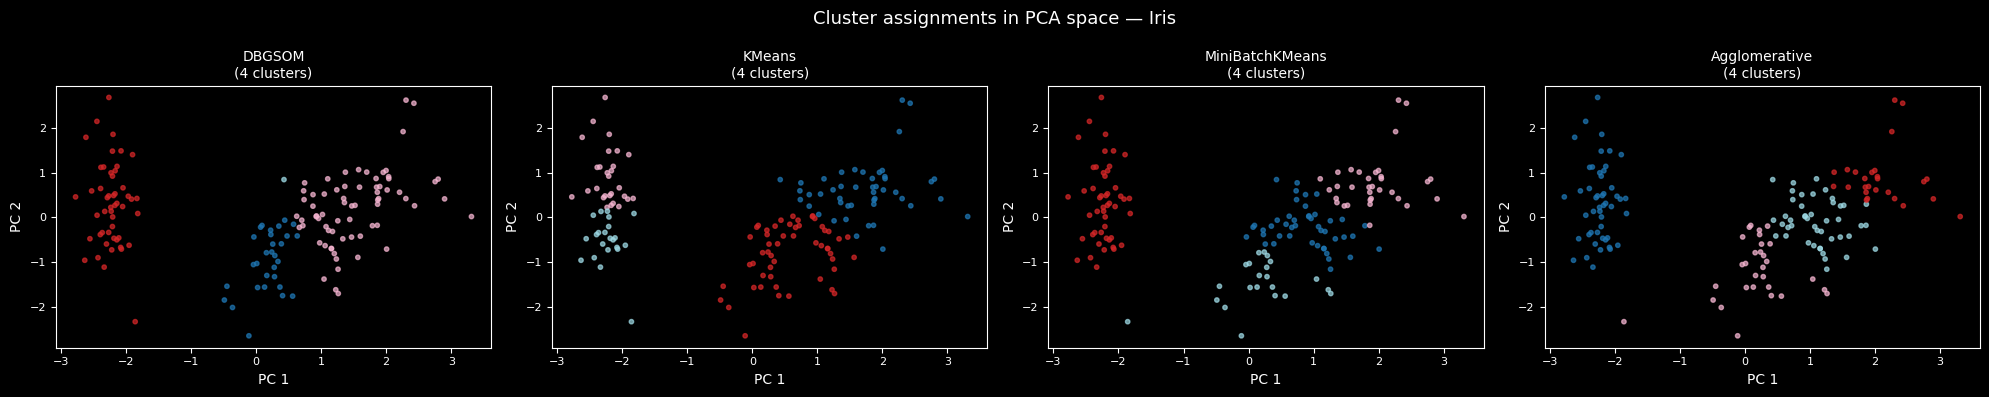

In [17]:
plot_pca_clusters(
    X_iris,
    {
        "DBGSOM": labels_som,
        "KMeans": labels_km,
        "MiniBatchKMeans": labels_mbkm,
        "Agglomerative": labels_agg,
    },
    "Iris",
)

---
## Dataset 2: Digits

1 797 samples, 64 features (8×8 pixel images of handwritten digits 0–9), 10 ground-truth classes.
A realistic, higher-dimensional dataset — the same one used in the MiniSom comparison notebook.

In [65]:
# --- DBGSOM (determines n_clusters for all other algorithms) ---
t0 = time.perf_counter()
som_digits = SomVQ(
    n_iter=300,
    spreading_factor=0.65,
    max_neurons=100,
    convergence_iter=15,
    random_state=42,
    verbose=True,
)
som_digits.fit(X_digits)
t_som_d = time.perf_counter() - t0
n_clusters_digits = len(som_digits.neurons_)
labels_som_d = som_digits.predict(X_digits)
print(f"DBGSOM:  {n_clusters_digits} neurons in {t_som_d:.3f}s")

# --- KMeans ---
t0 = time.perf_counter()
km_digits = KMeans(n_clusters=n_clusters_digits, random_state=42, n_init=10)
km_digits.fit(X_digits)
t_km_d = time.perf_counter() - t0
labels_km_d = km_digits.labels_
print(f"KMeans:  {n_clusters_digits} clusters in {t_km_d:.3f}s")

# --- MiniBatchKMeans ---
t0 = time.perf_counter()
mbkm_digits = MiniBatchKMeans(n_clusters=n_clusters_digits, random_state=42, n_init=10)
mbkm_digits.fit(X_digits)
t_mbkm_d = time.perf_counter() - t0
labels_mbkm_d = mbkm_digits.labels_
print(f"MiniBatch: {n_clusters_digits} clusters in {t_mbkm_d:.3f}s")

# --- AgglomerativeClustering ---
t0 = time.perf_counter()
agg_digits = AgglomerativeClustering(n_clusters=n_clusters_digits)
labels_agg_d = agg_digits.fit_predict(X_digits)
t_agg_d = time.perf_counter() - t0
print(f"Agglom.: {n_clusters_digits} clusters in {t_agg_d:.3f}s")

 54%|█████▍    | 163/300 [00:00<00:00, 728.84 epochs/s]


DBGSOM:  38 neurons in 0.245s
KMeans:  38 clusters in 0.155s
MiniBatch: 38 clusters in 0.134s
Agglom.: 38 clusters in 0.098s


### Metrics — Digits

In [66]:
rows_digits = [
    build_row(
        X_digits,
        y_digits,
        labels_som_d,
        "DBGSOM",
        t_som_d,
        qe=som_digits.quantization_error_,
        te=som_digits.topographic_error_,
    ),
    build_row(X_digits, y_digits, labels_km_d, "KMeans", t_km_d),
    build_row(X_digits, y_digits, labels_mbkm_d, "MiniBatchKMeans", t_mbkm_d),
    build_row(X_digits, y_digits, labels_agg_d, "AgglomerativeClustering", t_agg_d),
]

df_digits = pd.DataFrame(rows_digits).set_index("Algorithm")
df_digits

,Time (s),Clusters,ARI,Silhouette,Davies-Bouldin,Calinski-Harabasz,QE,Topographic Error
Algorithm,,,,,,,,
DBGSOM,0.245,38,0.417,0.066,2.403,44.6,5.0974,0.1091
KMeans,0.155,38,0.468,0.148,1.699,79.3,4.5755,—
MiniBatchKMeans,0.134,38,0.401,0.108,2.025,62.4,4.6681,—
AgglomerativeClustering,0.098,38,0.556,0.140,1.606,77.0,4.6515,—


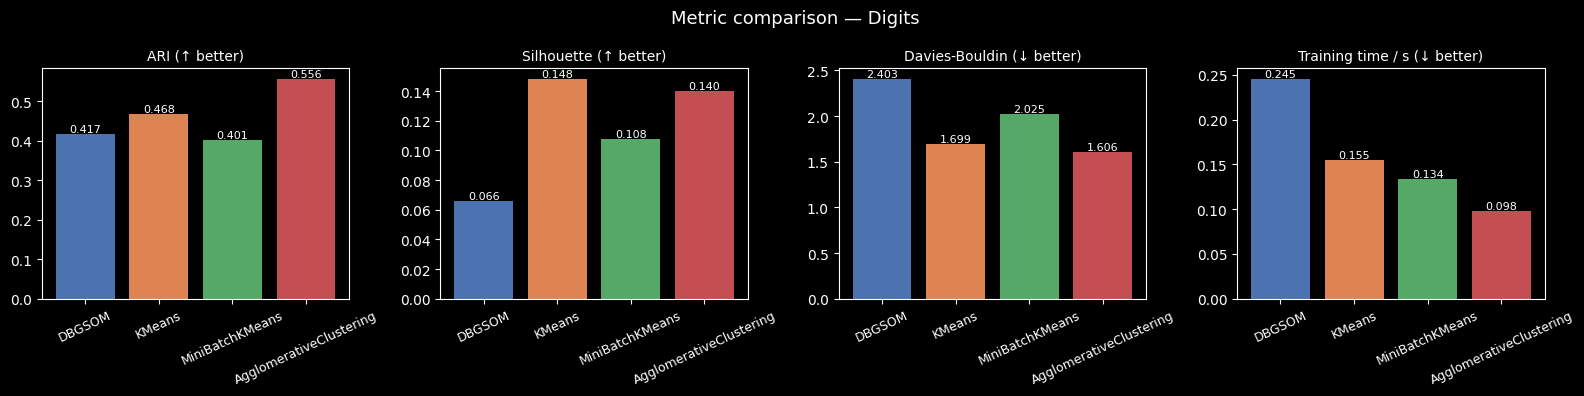

In [67]:
plot_metrics(rows_digits, "Digits")

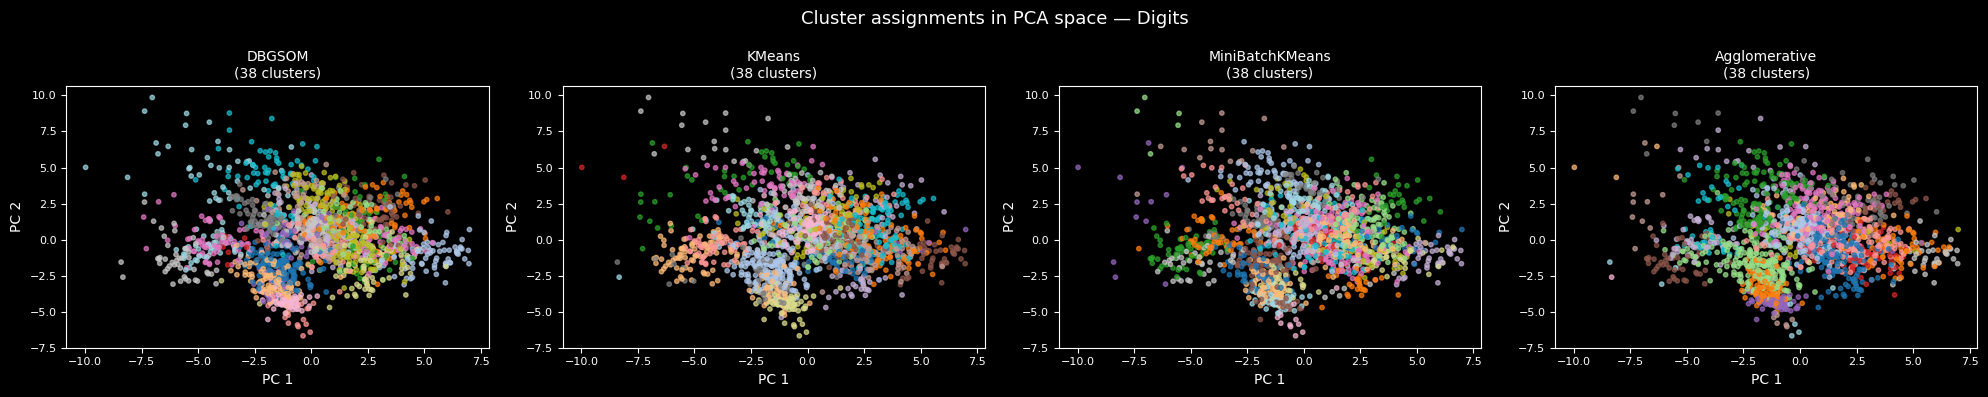

In [68]:
plot_pca_clusters(
    X_digits,
    {
        "DBGSOM": labels_som_d,
        "KMeans": labels_km_d,
        "MiniBatchKMeans": labels_mbkm_d,
        "Agglomerative": labels_agg_d,
    },
    "Digits",
)

### DBGSOM Map — Digits

DBGSOM also exposes the learned grid topology. The plot below shows each neuron in PCA space;
edges connect grid neighbours. Point size encodes how many training samples each neuron represents.

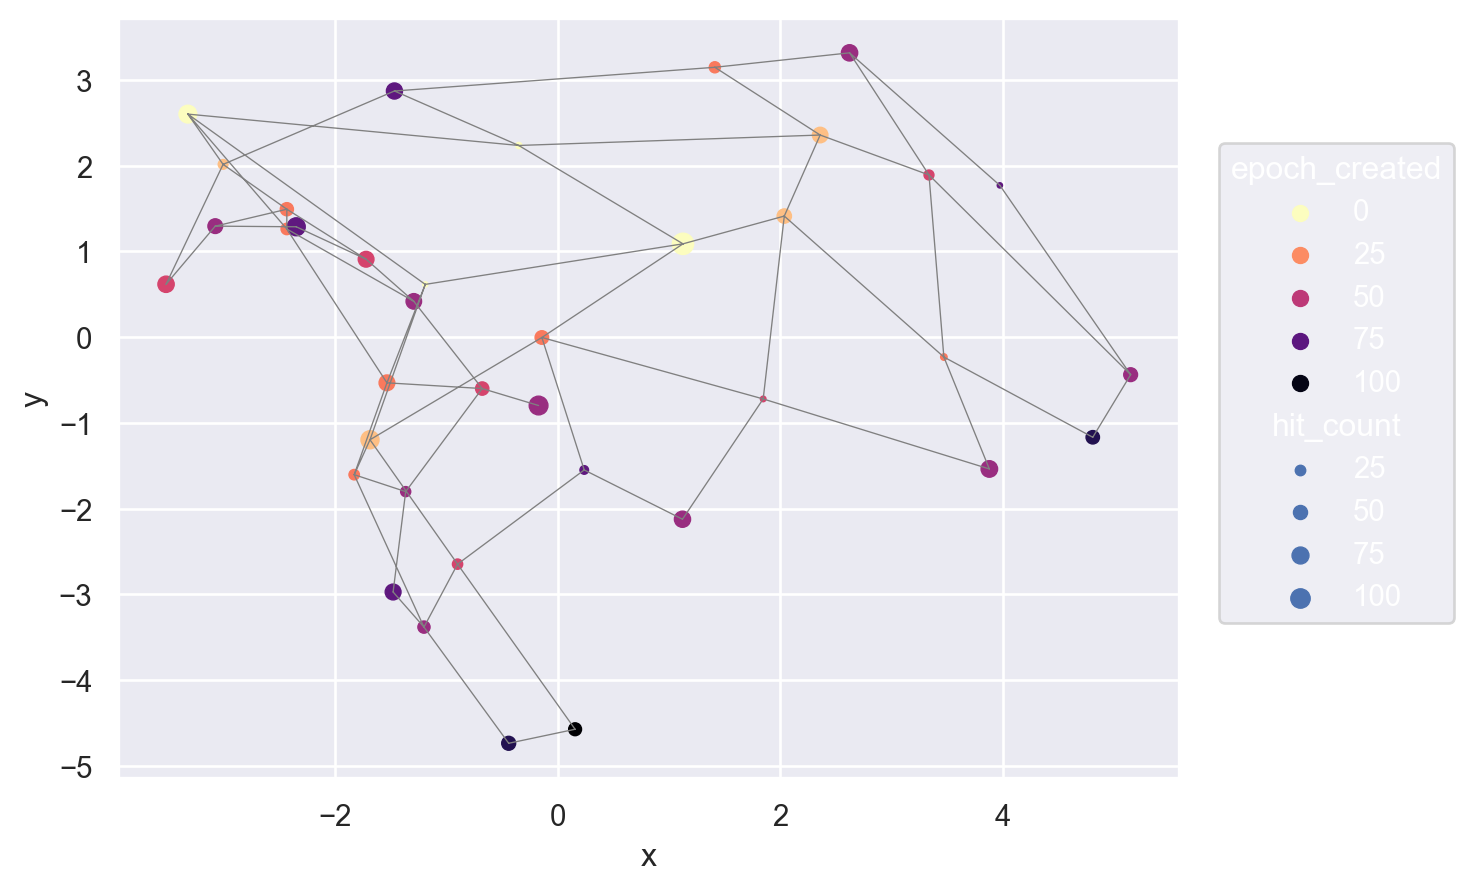

In [69]:
som_digits.plot(
    layout="pca", pointsize="hit_count", palette="magma_r", color="epoch_created"
)

---
## Summary

| Aspect | DBGSOM | KMeans | MiniBatchKMeans | AgglomerativeClustering |
| --- | --- | --- | --- | --- |
| **Best for** | Unknown map size; topology matters | Fast, general-purpose clustering | Large datasets, speed critical | Hierarchical structure; no predict needed |
| **Prototype count** | Determined automatically | Must be set in advance | Must be set in advance | Must be set in advance |
| **Topology** | Grid graph preserved | None | None | Dendrogram (not a grid) |
| **Predict on new data** | Yes | Yes | Yes | **No** |
| **sklearn pipeline** | Yes | Yes | Yes | Yes (fit only) |
| **Main cost** | Floyd-Warshall on growth steps | Iterative centroid updates | Mini-batch centroid updates | Pairwise distance matrix O(n²) |
| **Unique to DBGSOM** | Topographic error, `plot()`, `transform()` (sparse codes) | — | — | — |